# 04 — Clinical Validation: 3D Evaluation & Error Analysis

**Phase 4** of the BraTS-PEDs segmentation pipeline.

This notebook performs a full volumetric (3D) clinical validation of the best U-Net checkpoint (epoch 18).

| Section | Purpose |
|---|---|
| 1 | Imports & configuration |
| 2 | Model loading (best checkpoint — epoch 18) |
| 3 | Per-patient 3D evaluation loop (Dice + HD95 + post-processing) |
| 4 | Aggregate metrics summary table |
| 5 | Error analysis — 3 worst ET subjects |
| 6 | Visual failure analysis — zoomed overlays (GT vs Prediction) |

## Section 1 — Imports & Configuration

In [1]:
import os
import sys
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import torch
import segmentation_models_pytorch as smp

# Project root on sys.path so src.* imports work regardless of CWD
PROJECT_ROOT = os.path.dirname(os.path.abspath("04_evaluation.ipynb"))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.eval_utils import (
    get_subject_ids,
    predict_volume,
    remove_small_components,
    compute_dice_volume,
    compute_hd95_volume,
    CROP_SIZE, ORIG_SIZE, N_SLICES, CLASS_NAMES,
)
from src.train_utils import load_checkpoint

print(f"PyTorch  : {torch.__version__}")
print(f"CUDA     : {torch.cuda.is_available()}")
print(f"GPU      : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
print(f"SMP      : {smp.__version__}")

PyTorch  : 2.11.0+cu128
CUDA     : True
GPU      : NVIDIA GeForce RTX 3080 Laptop GPU
SMP      : 0.5.0


In [2]:
# ---------------------------------------------------------------------------
# Configuration — all path and hyper-parameter settings in one cell
# ---------------------------------------------------------------------------

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Checkpoint
CHECKPOINT_PATH = os.path.join(PROJECT_ROOT, "checkpoints", "unet", "best.pth")
HISTORY_PATH    = os.path.join(PROJECT_ROOT, "checkpoints", "unet", "history.json")

# Processed dataset
VAL_DATA_DIR = os.path.join(PROJECT_ROOT, "processed_dataset", "val")

# Original NIfTI root — needed for T1c channel extraction during plotting
NIFTI_ROOT = os.path.join(
    PROJECT_ROOT,
    "PKG - BraTS-PEDs-v1", "BraTS-PEDs-v1", "Training",
)

# Model architecture (must match training configuration)
ENCODER       = "resnet34"
ENCODER_WEIGHTS = "imagenet"
IN_CHANNELS   = 4
NUM_CLASSES   = 4

# Post-processing threshold
MIN_COMPONENT_VOXELS = 50

# BraTS-PEDs isotropic voxel spacing (mm)
VOXEL_SPACING = (1.0, 1.0, 1.0)

# Worst-N subjects to visualise in Error Analysis
N_WORST = 3

# Visual overlay padding (px) around the tumour bounding box
BB_PAD = 20

print("Configuration:")
print(f"  Device            : {DEVICE}")
print(f"  Checkpoint        : {CHECKPOINT_PATH}")
print(f"  Val data dir      : {VAL_DATA_DIR}")
print(f"  NIfTI root        : {NIFTI_ROOT}")
print(f"  Post-proc min vox : {MIN_COMPONENT_VOXELS}")
print(f"  Voxel spacing     : {VOXEL_SPACING} mm")

Configuration:
  Device            : cuda
  Checkpoint        : c:\Users\lrnzp\OneDrive\Desktop\POLITO\MAGISTRALE\Secondo Anno\Primo Semestre\AI in Medicine\Project\checkpoints\unet\best.pth
  Val data dir      : c:\Users\lrnzp\OneDrive\Desktop\POLITO\MAGISTRALE\Secondo Anno\Primo Semestre\AI in Medicine\Project\processed_dataset\val
  NIfTI root        : c:\Users\lrnzp\OneDrive\Desktop\POLITO\MAGISTRALE\Secondo Anno\Primo Semestre\AI in Medicine\Project\PKG - BraTS-PEDs-v1\BraTS-PEDs-v1\Training
  Post-proc min vox : 50
  Voxel spacing     : (1.0, 1.0, 1.0) mm


## Section 2 — Model Loading (best checkpoint — epoch 18)

In [3]:
# Instantiate architecture (identical to 03_train_unet.ipynb)
model = smp.Unet(
    encoder_name=ENCODER,
    encoder_weights=None,    # weights loaded from checkpoint, not ImageNet
    in_channels=IN_CHANNELS,
    classes=NUM_CLASSES,
    activation=None,
).to(DEVICE)

# Load best checkpoint — inference only; optimizer/scheduler not needed
ckpt = load_checkpoint(CHECKPOINT_PATH, model, device=DEVICE)

epoch_saved   = ckpt["epoch"]
ckpt_metrics  = ckpt.get("metrics", {})
val_fg_dice   = ckpt_metrics.get("val_fg_dice", float("nan"))

model.eval()

print(f"Checkpoint loaded  : epoch {epoch_saved}")
print(f"Val fg Dice (2D)   : {val_fg_dice:.4f}")
print(f"Model parameters   : {sum(p.numel() for p in model.parameters()):,}")
print(f"Model device       : {next(model.parameters()).device}")

Checkpoint loaded  : epoch 18
Val fg Dice (2D)   : nan
Model parameters   : 24,439,940
Model device       : cuda:0


## Section 3 — Per-Patient 3D Evaluation Loop

For each validation subject:
1. Run `predict_volume` (slice-by-slice, with centre-crop consistency)
2. Apply `remove_small_components` (26-conn, threshold 50 voxels)
3. Compute 3D Dice and HD95 per class
4. Accumulate results in a list of dicts → DataFrame

In [4]:
from tqdm.notebook import tqdm as tqdm_nb

subject_ids = get_subject_ids(VAL_DATA_DIR)
print(f"Validation subjects found: {len(subject_ids)}")
print("First 5:", subject_ids[:5])

Validation subjects found: 26
First 5: ['BraTS-PED-00004-000', 'BraTS-PED-00013-000', 'BraTS-PED-00019-000', 'BraTS-PED-00047-000', 'BraTS-PED-00054-000']


In [5]:
records = []

# Catch medpy RuntimeWarnings per-subject without aborting
with warnings.catch_warnings(record=True) as caught_warnings:
    warnings.simplefilter("always", RuntimeWarning)

    for subject_id in tqdm_nb(subject_ids, desc="Evaluating subjects"):
        # ── 1. 3D inference ──────────────────────────────────────────────────
        pred_raw, gt_vol = predict_volume(
            model, VAL_DATA_DIR, subject_id, DEVICE
        )

        # ── 2. Post-processing ───────────────────────────────────────────────
        pred_pp = remove_small_components(pred_raw, min_voxels=MIN_COMPONENT_VOXELS)

        # ── 3. Dice (on post-processed prediction) ───────────────────────────
        dice = compute_dice_volume(pred_pp, gt_vol)

        # ── 4. HD95 (on post-processed prediction) ───────────────────────────
        hd95 = compute_hd95_volume(pred_pp, gt_vol, voxel_spacing=VOXEL_SPACING)

        # ── 5. Accumulate ────────────────────────────────────────────────────
        record = {"subject_id": subject_id}
        record.update(dice)
        record.update(hd95)
        records.append(record)

# Summary of edge-case warnings encountered during evaluation
if caught_warnings:
    print(f"\n[Edge-case warnings during evaluation: {len(caught_warnings)}]")
    for w in caught_warnings:
        print(f"  {w.category.__name__}: {w.message}")
else:
    print("\nNo edge-case warnings — all HD95 values computed normally.")

print(f"\nEvaluation complete: {len(records)} subjects processed.")

Evaluating subjects:   0%|          | 0/26 [00:00<?, ?it/s]


[Edge-case warnings during evaluation: 12]

Evaluation complete: 26 subjects processed.


## Section 4 — Aggregate Metrics Summary

In [6]:
df = pd.DataFrame(records).set_index("subject_id")

print(f"Results DataFrame shape: {df.shape}")
print()
df.head()

Results DataFrame shape: (26, 7)



,dice_background,dice_NCR,dice_ED,dice_ET,hd95_NCR,hd95_ED,hd95_ET
subject_id,,,,,,,
BraTS-PED-00004-000,0.998150,0.475474,0.640127,0.398863,16.223412,9.000000,23.931147
BraTS-PED-00013-000,0.999047,1.000000,0.881244,1.000000,NaN,8.306624,NaN
BraTS-PED-00019-000,0.998977,0.773116,0.000102,0.834099,2.449490,30.083218,5.000000
BraTS-PED-00047-000,0.999603,0.814606,0.804084,1.000000,10.488088,6.053796,NaN
BraTS-PED-00054-000,0.999840,1.000000,0.939591,1.000000,NaN,2.000000,NaN


In [7]:
# ---------------------------------------------------------------------------
# Aggregate statistics
# ---------------------------------------------------------------------------
# Dice: nanmean (all should be defined, but safe)
# HD95: nanmean to exclude Case A/B/C edge cases from the mean

TUMOUR_CLASSES = ["NCR", "ED", "ET"]

summary_rows = []
for cls in TUMOUR_CLASSES:
    dice_col = f"dice_{cls}"
    hd95_col = f"hd95_{cls}"

    dice_vals = df[dice_col].values
    hd95_vals = df[hd95_col].values

    n_hd95_valid  = int(np.sum(~np.isnan(hd95_vals)))
    n_hd95_nan    = int(np.sum( np.isnan(hd95_vals)))

    summary_rows.append({
        "Class"          : cls,
        "Dice mean"      : f"{np.nanmean(dice_vals):.4f}",
        "Dice std"       : f"{np.nanstd(dice_vals):.4f}",
        "Dice min"       : f"{np.nanmin(dice_vals):.4f}",
        "Dice max"       : f"{np.nanmax(dice_vals):.4f}",
        "HD95 mean (mm)" : f"{np.nanmean(hd95_vals):.2f}" if n_hd95_valid > 0 else "N/A",
        "HD95 std (mm)"  : f"{np.nanstd(hd95_vals):.2f}"  if n_hd95_valid > 0 else "N/A",
        "HD95 min (mm)"  : f"{np.nanmin(hd95_vals):.2f}"  if n_hd95_valid > 0 else "N/A",
        "HD95 max (mm)"  : f"{np.nanmax(hd95_vals):.2f}"  if n_hd95_valid > 0 else "N/A",
        "HD95 NaN count" : n_hd95_nan,
    })

# Mean foreground Dice (NCR + ED + ET)
fg_dice_cols = [f"dice_{c}" for c in TUMOUR_CLASSES]
mean_fg_dice = np.nanmean(df[fg_dice_cols].values)

summary_df = pd.DataFrame(summary_rows).set_index("Class")

print("=" * 70)
print(f"  VALIDATION SET — 3D CLINICAL METRICS  (n={len(df)} subjects)")
print("=" * 70)
print(summary_df.to_string())
print()
print(f"  Mean foreground Dice (3D, post-processed): {mean_fg_dice:.4f}")
print("=" * 70)

  VALIDATION SET — 3D CLINICAL METRICS  (n=26 subjects)
      Dice mean Dice std Dice min Dice max HD95 mean (mm) HD95 std (mm) HD95 min (mm) HD95 max (mm)  HD95 NaN count
Class                                                                                                              
NCR      0.5917   0.3718   0.0000   1.0000          10.70         13.73          1.41         55.27              12
ED       0.7003   0.3092   0.0000   0.9621           7.22          7.12          1.41         30.08               1
ET       0.5959   0.4437   0.0000   1.0000          16.19          8.79          5.00         30.40              19

  Mean foreground Dice (3D, post-processed): 0.6293


## Section 5 — Error Analysis: 3 Worst ET Subjects

Identify the 3 subjects with the **lowest 3D Dice score on the Enhancing Tumour (ET)** class after post-processing.

In [8]:
# Sort ascending on dice_ET → worst performers first
df_sorted_et = df[["dice_ET", "hd95_ET", "dice_NCR", "dice_ED"]].sort_values(
    "dice_ET", ascending=True
)

worst_subjects = df_sorted_et.index[:N_WORST].tolist()

print(f"3 worst subjects by ET Dice score:")
print()
print(
    df_sorted_et.head(N_WORST).rename(
        columns={
            "dice_ET" : "Dice ET",
            "hd95_ET" : "HD95 ET (mm)",
            "dice_NCR": "Dice NCR",
            "dice_ED" : "Dice ED",
        }
    ).to_string()
)
print()
print(f"Subjects selected for visual analysis: {worst_subjects}")

3 worst subjects by ET Dice score:

                          Dice ET  HD95 ET (mm)      Dice NCR       Dice ED
subject_id                                                                 
BraTS-PED-00105-000  2.098196e-10           NaN  5.091965e-01  8.817440e-01
BraTS-PED-00147-000  2.241650e-10           NaN  1.745201e-09  1.805054e-10
BraTS-PED-00212-000  6.891799e-10           NaN  1.000000e+00  9.606376e-01

Subjects selected for visual analysis: ['BraTS-PED-00105-000', 'BraTS-PED-00147-000', 'BraTS-PED-00212-000']


## Section 6 — Visual Failure Analysis

For each of the 3 worst ET subjects, plot a **1×3 panel**:
- **Left**: Cropped T1c MRI slice (axial, best GT cross-section)
- **Centre**: Cropped T1c + **Ground Truth** mask overlay (semi-transparent)
- **Right**: Cropped T1c + **Prediction** mask overlay (semi-transparent)

Masks are colourised: NCR=Red, ED=Green, ET=Yellow, Background=Transparent.  
The display region is automatically cropped to the tumour bounding box + 20 px padding.

In [9]:
import nibabel as nib

# ---------------------------------------------------------------------------
# Discrete colormap: 4 classes, background fully transparent
# ---------------------------------------------------------------------------
# RGBA rows: [Background, NCR, ED, ET]
_CMAP_RGBA = np.array([
    [0.0,  0.0,  0.0,  0.0],   # class 0 — Background : fully transparent
    [1.0,  0.0,  0.0,  0.5],   # class 1 — NCR        : Red,    alpha=0.5
    [0.0,  1.0,  0.0,  0.5],   # class 2 — ED         : Green,  alpha=0.5
    [1.0,  1.0,  0.0,  0.5],   # class 3 — ET         : Yellow, alpha=0.5
], dtype=np.float32)

SEG_CMAP = ListedColormap(_CMAP_RGBA[:, :3])  # 3-channel cmap for imshow


def _mask_to_rgba(mask_2d: np.ndarray) -> np.ndarray:
    """Convert a 2-D integer label map [H, W] → RGBA [H, W, 4] float32.

    Background (class 0) is fully transparent; tumour classes are
    colourised with alpha=0.5 so the underlying MRI is visible.

    Args:
        mask_2d: 2-D integer array with values in {0, 1, 2, 3}.

    Returns:
        RGBA float32 array shape [H, W, 4].
    """
    rgba = _CMAP_RGBA[mask_2d.astype(np.int32)]  # index lookup → [H, W, 4]
    return rgba


def _tumour_bbox_2d(
    gt_slice: np.ndarray,
    pred_slice: np.ndarray,
    pad: int = BB_PAD,
    img_h: int = ORIG_SIZE,
    img_w: int = ORIG_SIZE,
) -> tuple:
    """Compute a padded 2-D bounding box enclosing GT ∪ Pred tumour voxels.

    Args:
        gt_slice:   2-D integer GT label slice [H, W].
        pred_slice: 2-D integer Pred label slice [H, W].
        pad:        Pixel padding around the bounding box (default BB_PAD).
        img_h:      Image height for clamping (default ORIG_SIZE).
        img_w:      Image width for clamping (default ORIG_SIZE).

    Returns:
        Tuple (r_min, r_max, c_min, c_max) ready for array slicing.
        If no tumour voxels exist in either slice, returns the full image extent.
    """
    # Union of all foreground voxels in GT and prediction
    foreground = (gt_slice > 0) | (pred_slice > 0)
    rows = np.any(foreground, axis=1)
    cols = np.any(foreground, axis=0)

    if not rows.any() or not cols.any():
        # No tumour — show the full frame
        return 0, img_h, 0, img_w

    r_min = max(int(np.argmax(rows)) - pad, 0)
    r_max = min(img_h - int(np.argmax(rows[::-1])) + pad, img_h)
    c_min = max(int(np.argmax(cols)) - pad, 0)
    c_max = min(img_w - int(np.argmax(cols[::-1])) + pad, img_w)

    return r_min, r_max, c_min, c_max


def _best_gt_slice(gt_vol: np.ndarray, cls: int = 3) -> int:
    """Return the axial slice index with the largest GT cross-section for ``cls``.

    Args:
        gt_vol: 3-D integer GT volume [H, W, D].
        cls:    Label class to maximise (default 3 = ET).

    Returns:
        Integer slice index (axis 2) with the most ``cls`` voxels.
        Falls back to the central slice if the class is absent.
    """
    counts = [(gt_vol[:, :, sl] == cls).sum() for sl in range(gt_vol.shape[2])]
    best   = int(np.argmax(counts))
    if counts[best] == 0:
        # Class absent — fall back to slice with most foreground
        counts_fg = [(gt_vol[:, :, sl] > 0).sum() for sl in range(gt_vol.shape[2])]
        best = int(np.argmax(counts_fg)) if max(counts_fg) > 0 else gt_vol.shape[2] // 2
    return best


def plot_failure_analysis(
    subject_id: str,
    pred_pp: np.ndarray,
    gt_vol: np.ndarray,
    nifti_root: str,
    dice_et: float,
    hd95_et: float,
    save_path: str | None = None,
) -> None:
    """Render the 1×3 failure-analysis panel for a single subject.

    Panels (left→right):
        1. Cropped T1c MRI (normalised for display)
        2. T1c + Ground-Truth overlay
        3. T1c + Prediction overlay

    The display region is auto-zoomed to the GT ∪ Pred tumour bounding box
    plus BB_PAD pixels of context on each side.

    Args:
        subject_id:  BraTS subject identifier.
        pred_pp:     Post-processed 3D prediction [H, W, D].
        gt_vol:      3D ground-truth volume [H, W, D].
        nifti_root:  Path to NIfTI Training folder.
        dice_et:     ET Dice score for this subject (shown in title).
        hd95_et:     ET HD95 value in mm (shown in title).
        save_path:   If provided, saves the figure to this path.
    """
    # ── Load T1c volume for the background MRI ────────────────────────────
    t1c_path = os.path.join(nifti_root, subject_id, f"{subject_id}-t1c.nii.gz")
    t1c_vol  = nib.load(t1c_path).get_fdata().astype(np.float32)  # [H, W, D]

    # ── Select best slice (most ET voxels in GT) ──────────────────────────
    sl_idx = _best_gt_slice(gt_vol, cls=3)

    t1c_slice  = t1c_vol[:, :, sl_idx]      # [240, 240]
    gt_slice   = gt_vol[:, :, sl_idx]       # [240, 240]
    pred_slice = pred_pp[:, :, sl_idx]      # [240, 240]

    # ── Bounding box ──────────────────────────────────────────────────────
    r_min, r_max, c_min, c_max = _tumour_bbox_2d(gt_slice, pred_slice)

    # Crop all channels to the bounding box
    t1c_crop  = t1c_slice[r_min:r_max, c_min:c_max]
    gt_crop   = gt_slice [r_min:r_max, c_min:c_max]
    pred_crop = pred_slice[r_min:r_max, c_min:c_max]

    # Normalise T1c for display (min-max, clamp at 99.5th percentile)
    t1c_p995  = float(np.percentile(t1c_crop[t1c_crop > 0], 99.5)) if (t1c_crop > 0).any() else 1.0
    t1c_disp  = np.clip(t1c_crop, 0.0, t1c_p995) / (t1c_p995 + 1e-8)

    # Convert masks to RGBA overlays
    gt_rgba   = _mask_to_rgba(gt_crop)
    pred_rgba = _mask_to_rgba(pred_crop)

    # ── Figure ─────────────────────────────────────────────────────────────
    hd95_str = f"{hd95_et:.1f} mm" if not np.isnan(hd95_et) else "N/A (miss)"

    fig, axes = plt.subplots(1, 3, figsize=(14, 5))
    fig.suptitle(
        f"Subject: {subject_id}  |  Axial slice {sl_idx}\n"
        f"ET Dice = {dice_et:.4f}   ET HD95 = {hd95_str}",
        fontsize=11,
        fontweight="bold",
    )

    # Panel 1 — T1c MRI only
    axes[0].imshow(t1c_disp, cmap="gray", interpolation="nearest")
    axes[0].set_title("T1c (cropped)", fontsize=10)
    axes[0].axis("off")

    # Panel 2 — T1c + GT overlay
    axes[1].imshow(t1c_disp, cmap="gray", interpolation="nearest")
    axes[1].imshow(gt_rgba, interpolation="nearest")
    axes[1].set_title("Ground Truth overlay", fontsize=10)
    axes[1].axis("off")

    # Panel 3 — T1c + Prediction overlay
    axes[2].imshow(t1c_disp, cmap="gray", interpolation="nearest")
    axes[2].imshow(pred_rgba, interpolation="nearest")
    axes[2].set_title("Prediction overlay", fontsize=10)
    axes[2].axis("off")

    # Legend (shared across panels)
    legend_patches = [
        mpatches.Patch(facecolor=(1, 0, 0, 0.7), label="NCR"),
        mpatches.Patch(facecolor=(0, 1, 0, 0.7), label="ED"),
        mpatches.Patch(facecolor=(1, 1, 0, 0.7), label="ET"),
    ]
    fig.legend(
        handles=legend_patches,
        loc="lower center",
        ncol=3,
        fontsize=9,
        framealpha=0.8,
        bbox_to_anchor=(0.5, -0.02),
    )

    plt.tight_layout(rect=[0, 0.04, 1, 1])

    if save_path is not None:
        os.makedirs(os.path.dirname(save_path) or ".", exist_ok=True)
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"  Saved → {save_path}")

    plt.show()
    plt.close(fig)


print("Plotting utilities defined.")

Plotting utilities defined.


Generating failure analysis plots for: ['BraTS-PED-00105-000', 'BraTS-PED-00147-000', 'BraTS-PED-00212-000']

[1/3] BraTS-PED-00105-000
  Saved → c:\Users\lrnzp\OneDrive\Desktop\POLITO\MAGISTRALE\Secondo Anno\Primo Semestre\AI in Medicine\Project\EDA_02_outputs\failure_analysis_rank01_BraTS-PED-00105-000.png


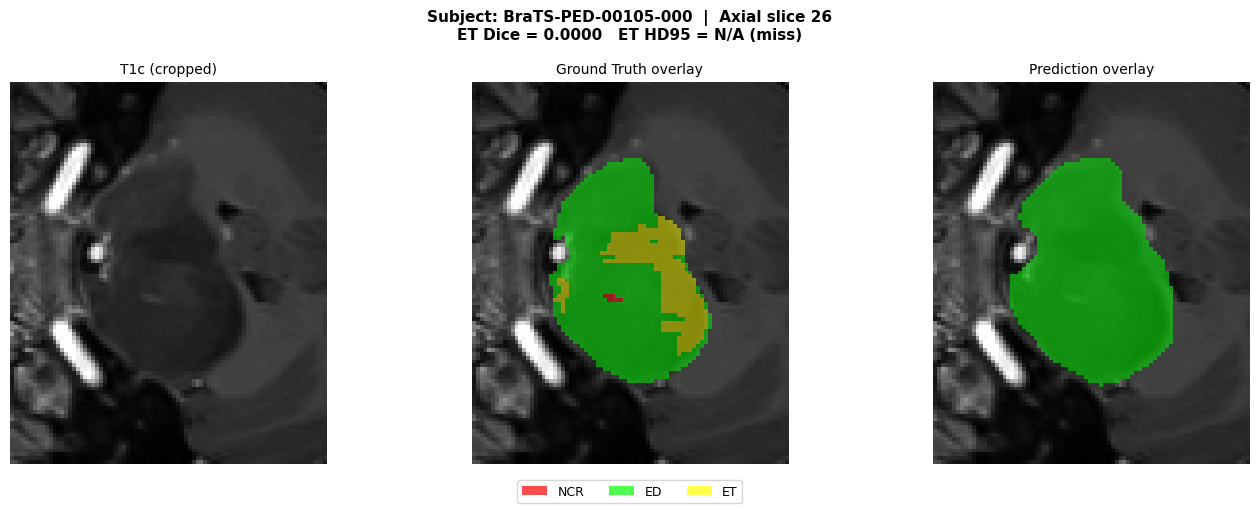

[2/3] BraTS-PED-00147-000
  Saved → c:\Users\lrnzp\OneDrive\Desktop\POLITO\MAGISTRALE\Secondo Anno\Primo Semestre\AI in Medicine\Project\EDA_02_outputs\failure_analysis_rank02_BraTS-PED-00147-000.png


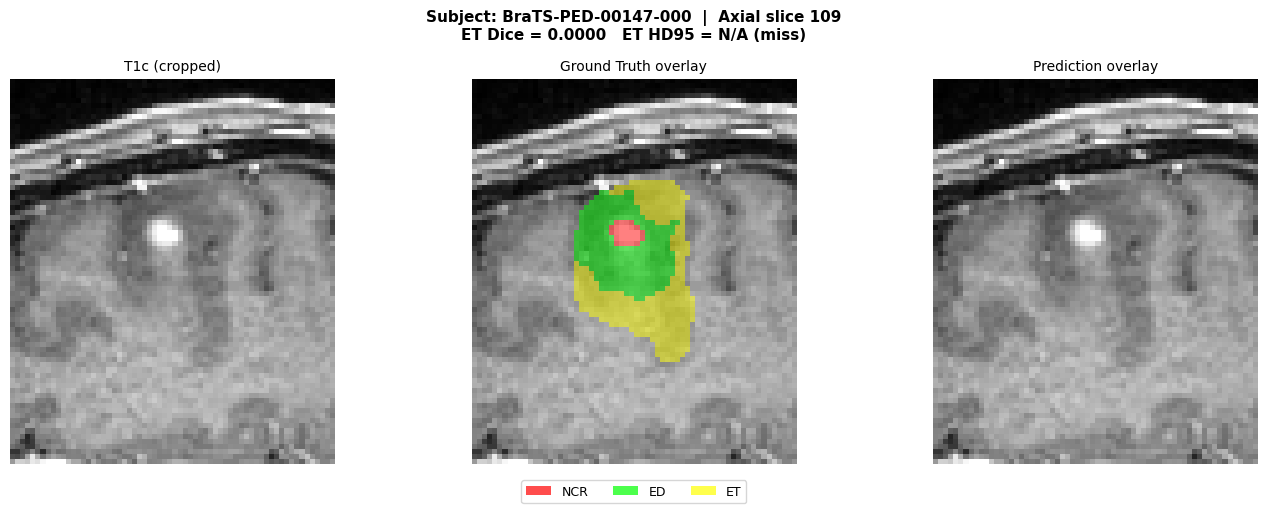

[3/3] BraTS-PED-00212-000
  Saved → c:\Users\lrnzp\OneDrive\Desktop\POLITO\MAGISTRALE\Secondo Anno\Primo Semestre\AI in Medicine\Project\EDA_02_outputs\failure_analysis_rank03_BraTS-PED-00212-000.png


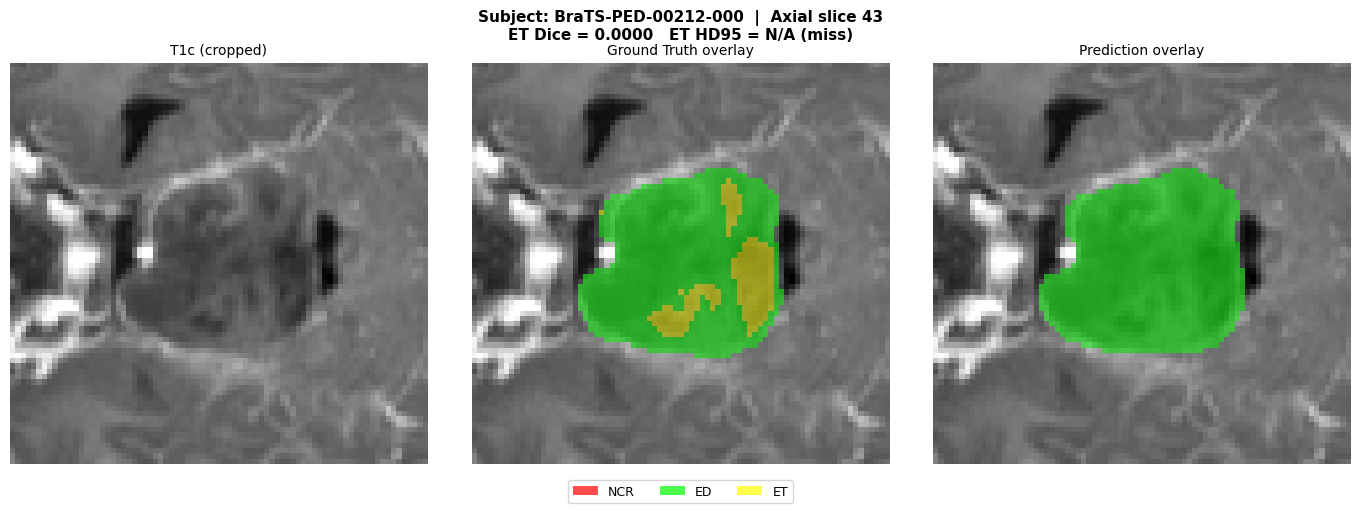


All failure analysis plots generated.


In [10]:
# ---------------------------------------------------------------------------
# Re-run inference for the 3 worst subjects and render the failure panels
# ---------------------------------------------------------------------------
# We re-run predict_volume (not cached) to avoid holding all 26 volumes in RAM.

OUTPUT_DIR = os.path.join(PROJECT_ROOT, "EDA_02_outputs")

print(f"Generating failure analysis plots for: {worst_subjects}")
print()

for rank, subject_id in enumerate(worst_subjects, start=1):
    print(f"[{rank}/{N_WORST}] {subject_id}")

    # Re-infer (clean state, no AMP context needed — model already on device)
    pred_raw, gt_vol = predict_volume(
        model, VAL_DATA_DIR, subject_id, DEVICE
    )
    pred_pp = remove_small_components(pred_raw, min_voxels=MIN_COMPONENT_VOXELS)

    dice_et = float(df.loc[subject_id, "dice_ET"])
    hd95_et = float(df.loc[subject_id, "hd95_ET"])

    save_path = os.path.join(
        OUTPUT_DIR,
        f"failure_analysis_rank{rank:02d}_{subject_id}.png",
    )

    plot_failure_analysis(
        subject_id=subject_id,
        pred_pp=pred_pp,
        gt_vol=gt_vol,
        nifti_root=NIFTI_ROOT,
        dice_et=dice_et,
        hd95_et=hd95_et,
        save_path=save_path,
    )

print("\nAll failure analysis plots generated.")

## Section 7 — Per-Subject Results Table (Full Validation Set)

In [11]:
# Full per-subject results sorted by mean foreground Dice (ascending)
df["mean_fg_dice"] = df[["dice_NCR", "dice_ED", "dice_ET"]].mean(axis=1)

display_cols = [
    "dice_NCR", "dice_ED", "dice_ET", "mean_fg_dice",
    "hd95_NCR", "hd95_ED", "hd95_ET",
]

df_display = df[display_cols].sort_values("mean_fg_dice", ascending=True)

# Format for readability
df_display = df_display.rename(columns={
    "dice_NCR"     : "Dice NCR",
    "dice_ED"      : "Dice ED",
    "dice_ET"      : "Dice ET",
    "mean_fg_dice" : "Dice mean (fg)",
    "hd95_NCR"     : "HD95 NCR (mm)",
    "hd95_ED"      : "HD95 ED (mm)",
    "hd95_ET"      : "HD95 ET (mm)",
})

pd.set_option("display.float_format", "{:.4f}".format)
df_display

,Dice NCR,Dice ED,Dice ET,Dice mean (fg),HD95 NCR (mm),HD95 ED (mm),HD95 ET (mm)
subject_id,,,,,,,
BraTS-PED-00147-000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN
BraTS-PED-00092-000,0.0399,0.2479,0.0795,0.1225,5.3852,9.0000,21.0000
BraTS-PED-00162-000,0.0000,0.0041,1.0000,0.3347,NaN,19.1050,NaN
BraTS-PED-00062-000,0.4328,0.8009,0.0000,0.4112,7.6321,3.1623,NaN
BraTS-PED-00108-000,0.3828,0.8858,0.0000,0.4229,8.3066,2.4495,NaN
BraTS-PED-00104-000,0.5368,0.7857,0.0000,0.4408,6.1644,3.3166,30.4023
BraTS-PED-00122-000,0.5332,0.4888,0.3474,0.4565,3.1623,5.0000,14.7986
BraTS-PED-00105-000,0.5092,0.8817,0.0000,0.4636,23.7908,6.4031,NaN
BraTS-PED-00070-000,0.6992,0.7229,0.0000,0.4740,4.1231,4.5826,NaN
